> **UFH DIRISA 2026 — Submission Notebook 6/6**  
> Project: *Eastern Cape Municipal Electoral Dynamics*  
> Scope: Eastern Cape Local Government Elections, 2000–2021 historical evidence with model-based 2026 scenarios.  
> Reproducibility rule: run notebooks in numerical order from the repository root.


# Phase 6 — 2026 Model-Based Scenarios

## Eastern Cape Municipal Electoral Dynamics

This final analytical phase converts the validated historical evidence from Phases 4 and 5 into **2026 model-based scenarios**.

### Purpose

The notebook produces municipality-level scenarios for:

1. **voter turnout**, and
2. **PR party vote-share composition**.

### Critical interpretation rule

These outputs are **not known 2026 election results** and are not statements about what will definitely happen.

They are conditional model-based scenarios constructed from:

- historical Eastern Cape local-election results;
- the historical validation completed in Phases 4 and 5;
- the latest available electoral state in the project (2021);
- 2022 municipality demographic information as descriptive context.

The historical backtests determine which methods are defensible. We do not select methods because they produce a preferred 2026 result.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("Run this notebook from inside the DIRISA project.")

PROJECT_ROOT = find_project_root()

PHASE1_DIR = PROJECT_ROOT / "data" / "processed" / "elections" / "phase1"
PHASE2_DIR = PROJECT_ROOT / "data" / "processed" / "demographics" / "phase2"
PHASE3_DIR = PROJECT_ROOT / "data" / "processed" / "panels" / "phase3"
PHASE4_DIR = PROJECT_ROOT / "data" / "processed" / "models" / "phase4"
PHASE5_DIR = PROJECT_ROOT / "data" / "processed" / "models" / "phase5"

PHASE6_DIR = PROJECT_ROOT / "data" / "processed" / "scenarios" / "phase6"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "phase6"

PHASE6_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Phase 6 output:", PHASE6_DIR.relative_to(PROJECT_ROOT))


Project root: C:\Users\Monwabisi05\IdeaProjects\Dirisa_TeamQualification
Phase 6 output: data\processed\scenarios\phase6


## 1. Load validated upstream outputs

Phase 6 deliberately depends on the processed outputs of earlier phases rather than rebuilding the historical data.

Required inputs:

- Phase 1 municipality election panel;
- Phase 1 selected party-share table;
- Phase 2 current/2022 demographics;
- Phase 4 historical turnout model comparison;
- Phase 5 historical party-support comparison and selected methods.


In [2]:
files = {
    "elections": PHASE1_DIR / "municipality_election_panel_2000_2021.csv",
    "party": PHASE1_DIR / "party_shares_selected_wide_2000_2021.csv",
    "demographics_2022": PHASE2_DIR / "demographics_current_2022.csv",
    "turnout_comparison": PHASE4_DIR / "turnout_model_comparison_2021.csv",
    "party_comparison": PHASE5_DIR / "party_support_model_comparison_2021.csv",
    "party_methods": PHASE5_DIR / "party_support_selected_methods.csv",
}

for name, path in files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required {name} file: {path}")

elections = pd.read_csv(files["elections"])
party = pd.read_csv(files["party"])
demo2022 = pd.read_csv(files["demographics_2022"])
turnout_eval = pd.read_csv(files["turnout_comparison"])
party_eval = pd.read_csv(files["party_comparison"])
party_methods = pd.read_csv(files["party_methods"])

print("Election panel:", elections.shape)
print("Party table:", party.shape)
print("2022 demographics:", demo2022.shape)
print("Turnout evaluation:", turnout_eval.shape)
print("Party evaluation:", party_eval.shape)
display(party_methods.round(3))


Election panel: (164, 20)
Party table: (164, 7)
2022 demographics: (33, 12)
Turnout evaluation: (5, 4)
Party evaluation: (30, 5)


,Party,Model,MAE_pts,RMSE_pts,R2
0,ANC,Random Forest,3.117,3.963,0.905
1,ATM,No Change Baseline,2.000,2.707,-1.203
2,DA,No Change Baseline,2.813,4.243,0.917
3,EFF,Average Swing Baseline,2.631,3.137,-0.034
4,OTHER,Random Forest,3.760,6.079,-0.518
5,UDM,No Change Baseline,0.997,1.649,0.801


## 2. Carry forward the historical validation evidence

### Turnout

Phase 4 compared simple baselines with Linear Regression, Ridge Regression and Random Forest.

For the **latest unseen historical holdout (2021)**, the lowest MAE in the saved Phase 4 comparison was:

> **Average Change Baseline — MAE = 7.725 percentage points**

The Average Change Baseline estimates the next election's turnout as:

> previous-election turnout + the mean turnout change learned from the historical training elections.

The Previous Turnout Baseline had a 2021 MAE of 8.204 percentage points, while the machine-learning models had larger errors.

Phase 6 therefore uses the **Average Change Baseline** for its central turnout scenario because that is the method selected by the actual Phase 4 holdout results. The notebook reads this selection from the saved Phase 4 output rather than hard-coding a preferred model.

The Phase 4 holdout MAE is carried forward as an empirical sensitivity scale. It is **not** a formal probabilistic confidence interval.

### Party support

Phase 5 found that the lowest-MAE historical method differed by party category. Phase 6 therefore uses the historically selected method for each category rather than forcing one algorithm across all parties.

The reconstructed 2021 party composition had:

- overall MAE: **2.502 percentage points**
- overall RMSE: **3.813 percentage points**
- historical top-category agreement: **32 of 33 municipalities**

These are historical backtest diagnostics, not guarantees of 2026 performance.


In [3]:
# Select the turnout method from the actual Phase 4 historical backtest.
# The 2021 holdout is the latest unseen historical election.

te = turnout_eval.copy()

if "TestYear" in te.columns:
    te_2021 = te[te["TestYear"] == 2021].copy()
else:
    te_2021 = te.copy()

if te_2021.empty:
    raise ValueError("No 2021 turnout backtest results found in Phase 4 output.")

required_eval_cols = {"Model", "MAE_pts", "RMSE_pts"}
missing_eval_cols = required_eval_cols - set(te_2021.columns)
if missing_eval_cols:
    raise ValueError(f"Phase 4 comparison is missing columns: {missing_eval_cols}")

display(te_2021.sort_values(["MAE_pts", "RMSE_pts"]).round(3))

best_turnout_row = (
    te_2021
    .sort_values(["MAE_pts", "RMSE_pts"])
    .iloc[0]
)

TURNOUT_METHOD = str(best_turnout_row["Model"])
TURNOUT_BACKTEST_MAE = float(best_turnout_row["MAE_pts"])
TURNOUT_BACKTEST_RMSE = float(best_turnout_row["RMSE_pts"])

print("Selected turnout method:", TURNOUT_METHOD)
print("Historical 2021 MAE:", round(TURNOUT_BACKTEST_MAE, 3), "percentage points")
print("Historical 2021 RMSE:", round(TURNOUT_BACKTEST_RMSE, 3), "percentage points")


,Model,MAE_pts,RMSE_pts,R2
0,Average Change Baseline,7.725,8.210,-3.436
1,Previous Turnout Baseline,8.204,8.662,-3.938
2,Random Forest,8.795,9.487,-4.923
3,Ridge Regression,9.428,9.975,-5.549
4,Linear Regression,9.527,10.080,-5.687


Selected turnout method: Average Change Baseline
Historical 2021 MAE: 7.725 percentage points
Historical 2021 RMSE: 8.21 percentage points


## 3. Build the 2026 feature state

The 2021 election provides the latest electoral state used by the scenario model.

For every municipality, the following 2021 quantities are available before the 2026 scenario:

- turnout;
- registered voters;
- ENP;
- victory margin;
- party vote shares.

The 2022 demographic table is joined as **contextual information**. It is not inserted into the historical party/turnout models, because those models were validated without it.


In [4]:
PARTIES = ["ANC", "DA", "EFF", "UDM", "ATM"]

p2021 = party[party["Year"] == 2021].copy()
e2021 = elections[elections["Year"] == 2021].copy()

assert len(p2021) == 33
assert len(e2021) == 33

p2021[PARTIES] = p2021[PARTIES].fillna(0.0)
p2021["OTHER"] = 100.0 - p2021[PARTIES].sum(axis=1)
p2021["OTHER"] = p2021["OTHER"].clip(lower=0)

MODEL_PARTIES = PARTIES + ["OTHER"]

state = e2021.merge(
    p2021[["MuniCode"] + MODEL_PARTIES],
    on="MuniCode",
    how="inner",
    validate="one_to_one"
)

assert len(state) == 33

# Join 2022 demographic context when MuniCode is available.
if "MuniCode" not in demo2022.columns:
    raise ValueError("demographics_current_2022.csv must contain MuniCode.")

demo_cols = [x for x in demo2022.columns if x != "Year"]
state = state.merge(
    demo2022[demo_cols],
    on="MuniCode",
    how="left",
    validate="one_to_one",
    suffixes=("", "_demo")
)

print("2026 scenario state rows:", len(state))
display(state.head())


2026 scenario state rows: 33


,MuniCode,RegisteredVoters,SpoiltVotes,VotingDistricts,ValidVotes,VotesCast,Turnout_%,Year,TopShare_%,Margin_pts,ENP,NumberOfParties,PreviousRegisteredVoters,PreviousTurnout_%,PreviousENP,PreviousMargin_pts,PreviousTopShare_%,TurnoutChange_pts,ENPChange,MarginChange_pts,ANC,DA,EFF,UDM,ATM,OTHER,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,CurrentFeatureSource
0,BUF,406486,3571,351,180265,183836,45.225666,2021,60.510914,41.017946,2.381045,26,419044.0,55.749516,2.369499,36.412729,59.864250,-10.523850,0.011547,4.605217,60.510914,19.492969,12.371231,1.10393,0.889246,5.631709,975255,24.8,7.8,30,4.1,33.6,15.0,85.6,83.7,94.6,clean_census.csv 2022 snapshot; richer scraper...
1,EC101,39913,272,46,18433,18705,46.864430,2021,46.628330,6.862692,2.632657,8,40887.0,61.310441,2.100601,4.617751,51.021895,-14.446011,0.532056,2.244941,46.628330,39.765638,4.123040,0.00000,0.146476,9.336516,101001,28.3,8.1,28,4.2,27.4,8.0,97.2,98.1,97.3,clean_census.csv 2022 snapshot; richer scraper...
2,EC102,17867,118,29,9310,9428,52.767672,2021,56.498389,19.441461,2.172260,4,18372.0,59.830176,1.990962,20.816439,59.408404,-7.062504,0.181297,-1.374979,56.498389,37.056928,6.176155,0.00000,0.268528,0.000000,49883,25.0,9.2,31,7.8,27.2,7.7,97.2,87.4,92.2,clean_census.csv 2022 snapshot; richer scraper...
3,EC104,43664,732,39,18011,18743,42.925522,2021,51.818333,32.963189,2.945774,9,46398.0,52.586318,2.054931,33.104138,62.832854,-9.660796,0.890843,-0.140949,51.818333,17.666981,5.829771,0.00000,0.827272,23.857643,97815,21.9,8.2,31,3.8,29.6,16.6,89.6,89.7,95.2,clean_census.csv 2022 snapshot; richer scraper...
4,EC105,33201,275,29,18163,18438,55.534472,2021,52.551891,22.265044,2.562510,5,34455.0,65.232912,2.058081,31.390437,62.331476,-9.698441,0.504429,-9.125392,52.551891,30.286847,14.799317,0.00000,0.280791,2.081154,87797,21.3,15.1,35,6.3,28.2,14.6,90.9,90.4,93.4,clean_census.csv 2022 snapshot; richer scraper...


## 4. Turnout scenario

The central turnout scenario must implement the **same method selected by Phase 4**.

For the current Phase 4 results, this is the **Average Change Baseline**.

The historical average change is learned from the same training elections used in the Phase 4 2021 backtest:

- target election 2011 relative to 2006;
- target election 2016 relative to 2011.

For each municipality:

> **2026 central turnout scenario = 2021 turnout + historical mean training turnout change**

The lower and upper sensitivity values are then:

- central scenario − historical 2021 MAE;
- central scenario + historical 2021 MAE.

All turnout values are clipped to 0–100%.

These are **MAE-based sensitivity bands**, not statistical confidence intervals.


In [5]:
# Reconstruct the turnout baseline using the same logic as Phase 4.

turnout_scenario = state[["MuniCode", "Turnout_%"]].copy()
turnout_scenario = turnout_scenario.rename(columns={"Turnout_%": "Turnout_2021"})

# Phase 4's 2021 training sample used the 2011 and 2016 target elections.
turnout_training = elections[elections["Year"].isin([2011, 2016])].copy()

required_turnout_cols = ["Turnout_%", "PreviousTurnout_%"]
if turnout_training[required_turnout_cols].isna().any().any():
    raise ValueError("Missing turnout values in the historical training observations.")

turnout_training["TurnoutChange_pts"] = (
    turnout_training["Turnout_%"] - turnout_training["PreviousTurnout_%"]
)

AVERAGE_TRAIN_TURNOUT_CHANGE = float(
    turnout_training["TurnoutChange_pts"].mean()
)

print(
    "Historical average turnout change learned from 2011 and 2016 training observations:",
    round(AVERAGE_TRAIN_TURNOUT_CHANGE, 3),
    "percentage points"
)

if TURNOUT_METHOD == "Average Change Baseline":
    turnout_scenario["TurnoutScenario_2026"] = (
        turnout_scenario["Turnout_2021"] + AVERAGE_TRAIN_TURNOUT_CHANGE
    ).clip(0, 100)

elif TURNOUT_METHOD == "Previous Turnout Baseline":
    turnout_scenario["TurnoutScenario_2026"] = (
        turnout_scenario["Turnout_2021"]
    ).clip(0, 100)

else:
    raise ValueError(
        f"Phase 4 selected '{TURNOUT_METHOD}'. "
        "This Phase 6 notebook currently supports the two validated baseline "
        "methods for the final turnout scenario. Review the scenario design "
        "before using a different selected model."
    )

turnout_scenario["TurnoutSensitivityLow_2026"] = (
    turnout_scenario["TurnoutScenario_2026"] - TURNOUT_BACKTEST_MAE
).clip(0, 100)

turnout_scenario["TurnoutSensitivityHigh_2026"] = (
    turnout_scenario["TurnoutScenario_2026"] + TURNOUT_BACKTEST_MAE
).clip(0, 100)

turnout_scenario["TurnoutMethod"] = TURNOUT_METHOD
turnout_scenario["HistoricalAverageChange_pts"] = AVERAGE_TRAIN_TURNOUT_CHANGE
turnout_scenario["HistoricalMAE_pts"] = TURNOUT_BACKTEST_MAE
turnout_scenario["HistoricalRMSE_pts"] = TURNOUT_BACKTEST_RMSE

display(turnout_scenario.head())


Historical average turnout change learned from 2011 and 2016 training observations:

 -0.479 percentage points


,MuniCode,Turnout_2021,TurnoutScenario_2026,TurnoutSensitivityLow_2026,TurnoutSensitivityHigh_2026,TurnoutMethod,HistoricalAverageChange_pts,HistoricalMAE_pts,HistoricalRMSE_pts
0,BUF,45.225666,44.747067,37.021800,52.472334,Average Change Baseline,-0.478599,7.725267,8.210444
1,EC101,46.864430,46.385831,38.660564,54.111098,Average Change Baseline,-0.478599,7.725267,8.210444
2,EC102,52.767672,52.289073,44.563806,60.014341,Average Change Baseline,-0.478599,7.725267,8.210444
3,EC104,42.925522,42.446923,34.721656,50.172190,Average Change Baseline,-0.478599,7.725267,8.210444
4,EC105,55.534472,55.055873,47.330606,62.781140,Average Change Baseline,-0.478599,7.725267,8.210444


## 5. Refit the party-support methods using all usable historical transitions

Phase 5 selected the lowest-MAE method separately for each category using the 2021 holdout.

For the final scenario:

1. preserve those selected method types;
2. refit model-based methods using the available 2016 and 2021 target-election observations;
3. use 2021 as the lagged state for the 2026 scenario.

### Why not add demographics here?

Adding new predictors after seeing the historical holdout would create a model that has not been validated under the same design. The final scenario therefore keeps the Phase 5 predictor structure unchanged.


In [6]:
# Build historical party transition panel exactly from Phase 1 outputs.

hist = party[["MuniCode", "Year"] + PARTIES].copy()
hist[PARTIES] = hist[PARTIES].fillna(0.0)
hist["OTHER"] = 100.0 - hist[PARTIES].sum(axis=1)
hist["OTHER"] = hist["OTHER"].clip(lower=0)
hist = hist.sort_values(["MuniCode", "Year"])

for p in MODEL_PARTIES:
    hist[f"prev_{p}"] = hist.groupby("MuniCode")[p].shift(1)
    hist[f"swing_{p}"] = hist[p] - hist[f"prev_{p}"]

context = elections[
    ["MuniCode", "Year", "PreviousTurnout_%",
     "PreviousENP", "PreviousMargin_pts", "PreviousRegisteredVoters"]
].copy()

hist = hist.merge(
    context,
    on=["MuniCode", "Year"],
    how="left",
    validate="one_to_one"
)

hist["LogPreviousRegisteredVoters"] = np.log1p(hist["PreviousRegisteredVoters"])

# Preserve the Phase 5 training design: 2016 and 2021 target elections.
refit = hist[hist["Year"].isin([2016, 2021])].copy()

assert len(refit) == 66

CONTEXT_FEATURES = [
    "PreviousTurnout_%",
    "PreviousENP",
    "PreviousMargin_pts",
    "LogPreviousRegisteredVoters",
]

def features_for(p):
    return [f"prev_{p}"] + CONTEXT_FEATURES

selected_methods = party_methods.set_index("Party")["Model"].to_dict()

print("Selected historical methods:")
for p in MODEL_PARTIES:
    print(f"{p:>6}: {selected_methods[p]}")


Selected historical methods:
   ANC: Random Forest
    DA: No Change Baseline
   EFF: Average Swing Baseline
   UDM: No Change Baseline
   ATM: No Change Baseline
 OTHER: Random Forest


In [7]:
# Construct the 2026 predictor frame from 2021 values.

scenario_X = state[[
    "MuniCode", "Turnout_%", "ENP", "Margin_pts", "RegisteredVoters"
] + MODEL_PARTIES].copy()

scenario_X["PreviousTurnout_%"] = scenario_X["Turnout_%"]
scenario_X["PreviousENP"] = scenario_X["ENP"]
scenario_X["PreviousMargin_pts"] = scenario_X["Margin_pts"]
scenario_X["PreviousRegisteredVoters"] = scenario_X["RegisteredVoters"]
scenario_X["LogPreviousRegisteredVoters"] = np.log1p(
    scenario_X["PreviousRegisteredVoters"]
)

for p in MODEL_PARTIES:
    scenario_X[f"prev_{p}"] = scenario_X[p]

display(scenario_X.head())


,MuniCode,Turnout_%,ENP,Margin_pts,RegisteredVoters,ANC,DA,EFF,UDM,ATM,OTHER,PreviousTurnout_%,PreviousENP,PreviousMargin_pts,PreviousRegisteredVoters,LogPreviousRegisteredVoters,prev_ANC,prev_DA,prev_EFF,prev_UDM,prev_ATM,prev_OTHER
0,BUF,45.225666,2.381045,41.017946,406486,60.510914,19.492969,12.371231,1.10393,0.889246,5.631709,45.225666,2.381045,41.017946,406486,12.915307,60.510914,19.492969,12.371231,1.10393,0.889246,5.631709
1,EC101,46.864430,2.632657,6.862692,39913,46.628330,39.765638,4.123040,0.00000,0.146476,9.336516,46.864430,2.632657,6.862692,39913,10.594482,46.628330,39.765638,4.123040,0.00000,0.146476,9.336516
2,EC102,52.767672,2.172260,19.441461,17867,56.498389,37.056928,6.176155,0.00000,0.268528,0.000000,52.767672,2.172260,19.441461,17867,9.790767,56.498389,37.056928,6.176155,0.00000,0.268528,0.000000
3,EC104,42.925522,2.945774,32.963189,43664,51.818333,17.666981,5.829771,0.00000,0.827272,23.857643,42.925522,2.945774,32.963189,43664,10.684302,51.818333,17.666981,5.829771,0.00000,0.827272,23.857643
4,EC105,55.534472,2.562510,22.265044,33201,52.551891,30.286847,14.799317,0.00000,0.280791,2.081154,55.534472,2.562510,22.265044,33201,10.410365,52.551891,30.286847,14.799317,0.00000,0.280791,2.081154


## 6. Generate raw party-share scenarios

The selected method is applied independently to each category.

- **No Change Baseline:** retain the 2021 share.
- **Average Swing Baseline:** add the average observed historical swing from the refit transitions.
- **Linear/Ridge/Random Forest:** predict swing and add it to the 2021 share.

Afterwards, all category predictions are constrained to a coherent 100% composition.


In [8]:
def build_model(model_name):
    if model_name == "Linear Regression":
        return make_pipeline(StandardScaler(), LinearRegression())
    if model_name == "Ridge Regression":
        return make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
        )
    if model_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=500,
            max_depth=3,
            min_samples_leaf=3,
            random_state=42
        )
    return None

raw_2026 = {}

for p in MODEL_PARTIES:
    method = selected_methods[p]
    previous = scenario_X[f"prev_{p}"].to_numpy()

    if method == "No Change Baseline":
        pred = previous.copy()

    elif method == "Average Swing Baseline":
        mean_swing = refit[f"swing_{p}"].mean()
        pred = previous + mean_swing

    else:
        feats = features_for(p)
        X_train = refit[feats]
        y_train = refit[f"swing_{p}"]
        X_2026 = scenario_X[feats]

        assert X_train.notna().all().all()
        assert X_2026.notna().all().all()

        model = build_model(method)
        model.fit(X_train, y_train)
        predicted_swing = model.predict(X_2026)
        pred = previous + predicted_swing

    raw_2026[p] = pred

raw_matrix = np.column_stack([raw_2026[p] for p in MODEL_PARTIES])

# Coherent composition
raw_matrix = np.clip(raw_matrix, 0, None)
row_sums = raw_matrix.sum(axis=1, keepdims=True)
assert (row_sums > 0).all()

share_matrix = 100 * raw_matrix / row_sums
assert np.allclose(share_matrix.sum(axis=1), 100.0)

party_scenario = scenario_X[["MuniCode"]].copy()

for i, p in enumerate(MODEL_PARTIES):
    party_scenario[f"{p}_2021"] = scenario_X[p].to_numpy()
    party_scenario[f"{p}_Scenario_2026"] = share_matrix[:, i]
    party_scenario[f"{p}_ChangeFrom2021_pts"] = (
        share_matrix[:, i] - scenario_X[p].to_numpy()
    )
    party_scenario[f"{p}_Method"] = selected_methods[p]

display(party_scenario.head())


,MuniCode,ANC_2021,ANC_Scenario_2026,ANC_ChangeFrom2021_pts,ANC_Method,DA_2021,DA_Scenario_2026,DA_ChangeFrom2021_pts,DA_Method,EFF_2021,EFF_Scenario_2026,EFF_ChangeFrom2021_pts,EFF_Method,UDM_2021,UDM_Scenario_2026,UDM_ChangeFrom2021_pts,UDM_Method,ATM_2021,ATM_Scenario_2026,ATM_ChangeFrom2021_pts,ATM_Method,OTHER_2021,OTHER_Scenario_2026,OTHER_ChangeFrom2021_pts,OTHER_Method
0,BUF,60.510914,54.847281,-5.663633,Random Forest,19.492969,18.733718,-0.759251,No Change Baseline,12.371231,15.653069,3.281838,Average Swing Baseline,1.10393,1.060932,-0.042998,No Change Baseline,0.889246,0.854610,-0.034636,No Change Baseline,5.631709,8.850389,3.218681,Random Forest
1,EC101,46.628330,42.763484,-3.864846,Random Forest,39.765638,42.232714,2.467076,No Change Baseline,4.123040,8.538034,4.414994,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.146476,0.155564,0.009087,No Change Baseline,9.336516,6.310204,-3.026312,Random Forest
2,EC102,56.498389,47.427894,-9.070495,Random Forest,37.056928,34.860624,-2.196304,No Change Baseline,6.176155,9.494229,3.318075,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.268528,0.252613,-0.015915,No Change Baseline,0.000000,7.964639,7.964639,Random Forest
3,EC104,51.818333,50.576477,-1.241857,Random Forest,17.666981,20.239814,2.572833,No Change Baseline,5.829771,11.165310,5.335540,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.827272,0.947747,0.120475,No Change Baseline,23.857643,17.070651,-6.786991,Random Forest
4,EC105,52.551891,43.912030,-8.639861,Random Forest,30.286847,28.713125,-1.573722,No Change Baseline,14.799317,17.743081,2.943764,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.280791,0.266201,-0.014590,No Change Baseline,2.081154,9.365563,7.284409,Random Forest


## 7. Party-share sensitivity bands

Phase 5's overall historical MAE was approximately **2.502 percentage points**.

For communication and dashboard use, each projected share receives an MAE-based sensitivity band of ± the historical overall MAE, clipped to 0–100%.

Again, these are **sensitivity bands**, not formal confidence intervals. They do not account for every possible source of election uncertainty, such as new parties, candidate changes, campaign effects, coalitions, shocks, or structural political change.


In [9]:
phase5_overall_file = PHASE5_DIR / "party_support_overall_metrics_2021.csv"
if not phase5_overall_file.exists():
    raise FileNotFoundError(phase5_overall_file)

phase5_overall = pd.read_csv(phase5_overall_file)
PARTY_BACKTEST_MAE = float(
    phase5_overall.loc[
        phase5_overall["Metric"] == "Overall party-share MAE",
        "Value_pts"
    ].iloc[0]
)

for p in MODEL_PARTIES:
    center = party_scenario[f"{p}_Scenario_2026"]
    party_scenario[f"{p}_SensitivityLow_2026"] = (
        center - PARTY_BACKTEST_MAE
    ).clip(0, 100)
    party_scenario[f"{p}_SensitivityHigh_2026"] = (
        center + PARTY_BACKTEST_MAE
    ).clip(0, 100)

print("Historical party-share MAE used for sensitivity:", round(PARTY_BACKTEST_MAE, 3))


Historical party-share MAE used for sensitivity: 2.502


## 8. Descriptive leading-category field

For dashboard and analytical summarisation, the notebook records the category with the largest modelled share in each municipality.

This field must always be described as:

> **the highest-share category under the model-based scenario**

It must **not** be presented as a statement that a party will win the 2026 election.


In [10]:
top_idx = share_matrix.argmax(axis=1)

party_scenario["ScenarioHighestShareCategory_2026"] = [
    MODEL_PARTIES[i] for i in top_idx
]
party_scenario["ScenarioHighestShare_2026"] = share_matrix.max(axis=1)

sorted_shares = np.sort(share_matrix, axis=1)
party_scenario["ScenarioTopTwoGap_pts_2026"] = (
    sorted_shares[:, -1] - sorted_shares[:, -2]
)

display(
    party_scenario[
        ["MuniCode", "ScenarioHighestShareCategory_2026",
         "ScenarioHighestShare_2026", "ScenarioTopTwoGap_pts_2026"]
    ].head()
)


,MuniCode,ScenarioHighestShareCategory_2026,ScenarioHighestShare_2026,ScenarioTopTwoGap_pts_2026
0,BUF,ANC,54.847281,36.113563
1,EC101,ANC,42.763484,0.530770
2,EC102,ANC,47.427894,12.567270
3,EC104,ANC,50.576477,30.336663
4,EC105,ANC,43.912030,15.198905


## 9. Combine turnout, party support and demographic context

This table is intended to be the primary Phase 6 dataset for the dashboard.

Demographic variables remain contextual descriptors. Their presence in the output does not imply that Phase 6 estimated causal demographic effects.


In [11]:
scenario_2026 = turnout_scenario.merge(
    party_scenario,
    on="MuniCode",
    how="inner",
    validate="one_to_one"
)

# Add current demographic context, avoiding duplicate electoral columns.
demo_context = demo2022.copy()
if "Year" in demo_context.columns:
    demo_context = demo_context.drop(columns=["Year"])

scenario_2026 = scenario_2026.merge(
    demo_context,
    on="MuniCode",
    how="left",
    validate="one_to_one"
)

assert len(scenario_2026) == 33
assert scenario_2026["MuniCode"].nunique() == 33

print("Final 2026 scenario table:", scenario_2026.shape)
display(scenario_2026.head())


Final 2026 scenario table: (33, 59)


,MuniCode,Turnout_2021,TurnoutScenario_2026,TurnoutSensitivityLow_2026,TurnoutSensitivityHigh_2026,TurnoutMethod,HistoricalAverageChange_pts,HistoricalMAE_pts,HistoricalRMSE_pts,ANC_2021,ANC_Scenario_2026,ANC_ChangeFrom2021_pts,ANC_Method,DA_2021,DA_Scenario_2026,DA_ChangeFrom2021_pts,DA_Method,EFF_2021,EFF_Scenario_2026,EFF_ChangeFrom2021_pts,EFF_Method,UDM_2021,UDM_Scenario_2026,UDM_ChangeFrom2021_pts,UDM_Method,ATM_2021,ATM_Scenario_2026,ATM_ChangeFrom2021_pts,ATM_Method,OTHER_2021,OTHER_Scenario_2026,OTHER_ChangeFrom2021_pts,OTHER_Method,ANC_SensitivityLow_2026,ANC_SensitivityHigh_2026,DA_SensitivityLow_2026,DA_SensitivityHigh_2026,EFF_SensitivityLow_2026,EFF_SensitivityHigh_2026,UDM_SensitivityLow_2026,UDM_SensitivityHigh_2026,ATM_SensitivityLow_2026,ATM_SensitivityHigh_2026,OTHER_SensitivityLow_2026,OTHER_SensitivityHigh_2026,ScenarioHighestShareCategory_2026,ScenarioHighestShare_2026,ScenarioTopTwoGap_pts_2026,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,CurrentFeatureSource
0,BUF,45.225666,44.747067,37.021800,52.472334,Average Change Baseline,-0.478599,7.725267,8.210444,60.510914,54.847281,-5.663633,Random Forest,19.492969,18.733718,-0.759251,No Change Baseline,12.371231,15.653069,3.281838,Average Swing Baseline,1.10393,1.060932,-0.042998,No Change Baseline,0.889246,0.854610,-0.034636,No Change Baseline,5.631709,8.850389,3.218681,Random Forest,52.345392,57.349171,16.231829,21.235607,13.151180,18.154958,0.0,3.562822,0.0,3.356500,6.348500,11.352279,ANC,54.847281,36.113563,975255,24.8,7.8,30,4.1,33.6,15.0,85.6,83.7,94.6,clean_census.csv 2022 snapshot; richer scraper...
1,EC101,46.864430,46.385831,38.660564,54.111098,Average Change Baseline,-0.478599,7.725267,8.210444,46.628330,42.763484,-3.864846,Random Forest,39.765638,42.232714,2.467076,No Change Baseline,4.123040,8.538034,4.414994,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.146476,0.155564,0.009087,No Change Baseline,9.336516,6.310204,-3.026312,Random Forest,40.261594,45.265373,39.730824,44.734603,6.036145,11.039924,0.0,2.501889,0.0,2.657453,3.808315,8.812094,ANC,42.763484,0.530770,101001,28.3,8.1,28,4.2,27.4,8.0,97.2,98.1,97.3,clean_census.csv 2022 snapshot; richer scraper...
2,EC102,52.767672,52.289073,44.563806,60.014341,Average Change Baseline,-0.478599,7.725267,8.210444,56.498389,47.427894,-9.070495,Random Forest,37.056928,34.860624,-2.196304,No Change Baseline,6.176155,9.494229,3.318075,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.268528,0.252613,-0.015915,No Change Baseline,0.000000,7.964639,7.964639,Random Forest,44.926005,49.929784,32.358735,37.362513,6.992340,11.996119,0.0,2.501889,0.0,2.754503,5.462750,10.466528,ANC,47.427894,12.567270,49883,25.0,9.2,31,7.8,27.2,7.7,97.2,87.4,92.2,clean_census.csv 2022 snapshot; richer scraper...
3,EC104,42.925522,42.446923,34.721656,50.172190,Average Change Baseline,-0.478599,7.725267,8.210444,51.818333,50.576477,-1.241857,Random Forest,17.666981,20.239814,2.572833,No Change Baseline,5.829771,11.165310,5.335540,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.827272,0.947747,0.120475,No Change Baseline,23.857643,17.070651,-6.786991,Random Forest,48.074587,53.078366,17.737925,22.741703,8.663421,13.667200,0.0,2.501889,0.0,3.449637,14.568762,19.572541,ANC,50.576477,30.336663,97815,21.9,8.2,31,3.8,29.6,16.6,89.6,89.7,95.2,clean_census.csv 2022 snapshot; richer scraper...
4,EC105,55.534472,55.055873,47.330606,62.781140,Average Change Baseline,-0.478599,7.725267,8.210444,52.551891,43.912030,-8.639861,Random Forest,30.286847,28.713125,-1.573722,No Change Baseline,14.799317,17.743081,2.943764,Average Swing Baseline,0.00000,0.000000,0.000000,No Change Baseline,0.280791,0.266201,-0.014590,No Change Baseline,2.081154,9.365563,7.284409,Random Forest,41.410141,46.413919,26.211236,31.215015,15.241192,20.244970,0.0,2.501889,0.0,2.768090,6.863674,11.867453,ANC,43.912030,15.198905,87797,21.3,15.1,35,6.3,28.2,14.6,90.9,90.4,93.4,clean_census.csv 2022 snapshot; r

## 10. Scenario summaries

These summaries describe the model output; they do not convert the scenarios into known outcomes.


In [12]:
summary_rows = []

summary_rows.append({
    "Measure": "Municipalities",
    "Value": len(scenario_2026)
})
summary_rows.append({
    "Measure": "Mean turnout scenario (%)",
    "Value": scenario_2026["TurnoutScenario_2026"].mean()
})
summary_rows.append({
    "Measure": "Turnout historical MAE used for sensitivity (pts)",
    "Value": TURNOUT_BACKTEST_MAE
})
summary_rows.append({
    "Measure": "Party-share historical MAE used for sensitivity (pts)",
    "Value": PARTY_BACKTEST_MAE
})

scenario_summary = pd.DataFrame(summary_rows)
display(scenario_summary.round(3))


,Measure,Value
0,Municipalities,33.000
1,Mean turnout scenario (%),47.547
2,Turnout historical MAE used for sensitivity (pts),7.725
3,Party-share historical MAE used for sensitivit...,2.502


In [13]:
category_counts = (
    scenario_2026["ScenarioHighestShareCategory_2026"]
    .value_counts()
    .rename_axis("ScenarioHighestShareCategory_2026")
    .reset_index(name="MunicipalityCount")
)

display(category_counts)


,ScenarioHighestShareCategory_2026,MunicipalityCount
0,ANC,31
1,DA,2


## 11. Visual diagnostics

The figures below visualise the scenario structure for analysis and presentation. They should retain the word **scenario** in captions/titles.


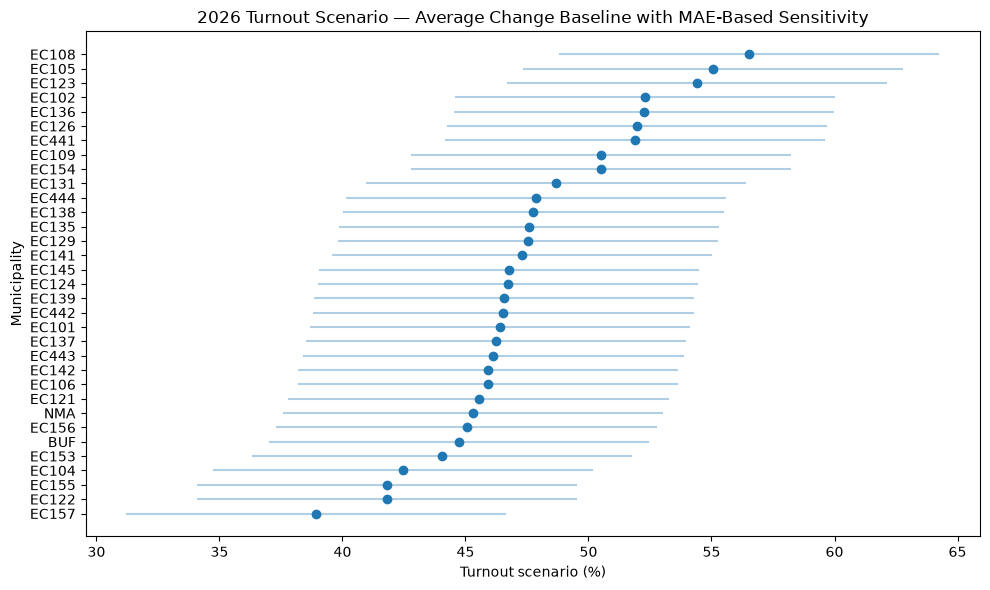

In [14]:
# Turnout scenario with historical-error sensitivity bands.
ordered = scenario_2026.sort_values("TurnoutScenario_2026")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ordered))

ax.scatter(ordered["TurnoutScenario_2026"], y)
ax.hlines(
    y,
    ordered["TurnoutSensitivityLow_2026"],
    ordered["TurnoutSensitivityHigh_2026"],
    alpha=0.35
)

ax.set_yticks(y)
ax.set_yticklabels(ordered["MuniCode"])
ax.set_xlabel("Turnout scenario (%)")
ax.set_ylabel("Municipality")
ax.set_title(
    f"2026 Turnout Scenario — {TURNOUT_METHOD} "
    "with MAE-Based Sensitivity"
)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "turnout_scenario_2026.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()


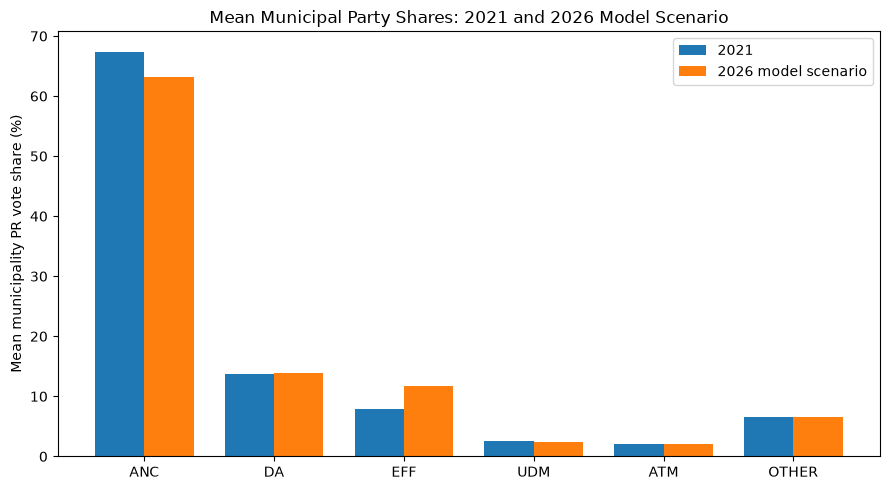

In [15]:
# Mean municipal party shares: 2021 vs scenario.
mean_2021 = np.array([scenario_2026[f"{p}_2021"].mean() for p in MODEL_PARTIES])
mean_2026 = np.array([scenario_2026[f"{p}_Scenario_2026"].mean() for p in MODEL_PARTIES])

x = np.arange(len(MODEL_PARTIES))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, mean_2021, width, label="2021")
ax.bar(x + width/2, mean_2026, width, label="2026 model scenario")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_PARTIES)
ax.set_ylabel("Mean municipality PR vote share (%)")
ax.set_title("Mean Municipal Party Shares: 2021 and 2026 Model Scenario")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "party_share_scenario_2026.png",
    dpi=180, bbox_inches="tight"
)
plt.show()


## 12. Quality control


In [16]:
qc = []

def add_check(name, passed, detail):
    qc.append({
        "Check": name,
        "Passed": bool(passed),
        "Detail": str(detail)
    })

add_check(
    "33 municipalities in final scenario",
    len(scenario_2026) == 33,
    len(scenario_2026)
)
add_check(
    "Unique municipality codes",
    scenario_2026["MuniCode"].nunique() == 33,
    scenario_2026["MuniCode"].nunique()
)
add_check(
    "Turnout scenario within 0-100",
    scenario_2026["TurnoutScenario_2026"].between(0, 100).all(),
    "all rows"
)

scenario_share_cols = [f"{p}_Scenario_2026" for p in MODEL_PARTIES]
share_sums = scenario_2026[scenario_share_cols].sum(axis=1)

add_check(
    "Party scenario shares sum to 100",
    np.allclose(share_sums, 100.0, atol=1e-6),
    f"min={share_sums.min():.6f}, max={share_sums.max():.6f}"
)
add_check(
    "Party scenario shares non-negative",
    (scenario_2026[scenario_share_cols] >= 0).all().all(),
    "all rows"
)
add_check(
    "Selected Phase 5 methods available",
    set(MODEL_PARTIES).issubset(selected_methods.keys()),
    selected_methods
)


expected_turnout = (
    scenario_2026["Turnout_2021"] + AVERAGE_TRAIN_TURNOUT_CHANGE
).clip(0, 100) if TURNOUT_METHOD == "Average Change Baseline" else scenario_2026["Turnout_2021"].clip(0, 100)

add_check(
    "Turnout scenario implements selected Phase 4 method",
    np.allclose(
        scenario_2026["TurnoutScenario_2026"],
        expected_turnout,
        atol=1e-10
    ),
    TURNOUT_METHOD
)

quality_control = pd.DataFrame(qc)
display(quality_control)

assert quality_control["Passed"].all(), "Phase 6 quality control failed."


,Check,Passed,Detail
0,33 municipalities in final scenario,True,33
1,Unique municipality codes,True,33
2,Turnout scenario within 0-100,True,all rows
3,Party scenario shares sum to 100,True,"min=100.000000, max=100.000000"
4,Party scenario shares non-negative,True,all rows
5,Selected Phase 5 methods available,True,"{'ANC': 'Random Forest', 'ATM': 'No Change Bas..."
6,Turnout scenario implements selected Phase 4 m...,True,Average Change Baseline


## 13. Save Phase 6 outputs


In [17]:
turnout_scenario.to_csv(
    PHASE6_DIR / "turnout_scenario_2026.csv",
    index=False
)
party_scenario.to_csv(
    PHASE6_DIR / "party_support_scenario_2026.csv",
    index=False
)
scenario_2026.to_csv(
    PHASE6_DIR / "municipality_scenarios_2026.csv",
    index=False
)
scenario_summary.to_csv(
    PHASE6_DIR / "scenario_summary_2026.csv",
    index=False
)
category_counts.to_csv(
    PHASE6_DIR / "scenario_highest_share_category_counts_2026.csv",
    index=False
)
quality_control.to_csv(
    PHASE6_DIR / "phase6_quality_control.csv",
    index=False
)

methodology = pd.DataFrame([
    ["Scenario year", "2026"],
    ["Geography", "33 harmonised Eastern Cape municipalities"],
    ["Turnout central method", TURNOUT_METHOD],
    ["Turnout historical average change", f"{AVERAGE_TRAIN_TURNOUT_CHANGE:.3f} pts"],
    ["Turnout sensitivity", f"± historical 2021 MAE ({TURNOUT_BACKTEST_MAE:.3f} pts)"],
    ["Party methods", "; ".join(f"{p}: {selected_methods[p]}" for p in MODEL_PARTIES)],
    ["Party sensitivity", f"± historical overall MAE ({PARTY_BACKTEST_MAE:.3f} pts)"],
    ["Demographics", "2022 municipality data used as contextual descriptors, not causal/model predictors"],
    ["Interpretation", "Model-based scenarios, not known election outcomes"],
], columns=["Item", "Value"])

methodology.to_csv(
    PHASE6_DIR / "phase6_methodology.csv",
    index=False
)

print("Saved Phase 6 outputs:")
for f in sorted(PHASE6_DIR.glob("*.csv")):
    print(" -", f.relative_to(PROJECT_ROOT))

print("\nSaved figures:")
for f in sorted(FIGURE_DIR.glob("*.png")):
    print(" -", f.relative_to(PROJECT_ROOT))

print("\nPhase 6 complete.")


Saved Phase 6 outputs:
 - data\processed\scenarios\phase6\municipality_scenarios_2026.csv
 - data\processed\scenarios\phase6\party_support_scenario_2026.csv
 - data\processed\scenarios\phase6\phase6_methodology.csv
 - data\processed\scenarios\phase6\phase6_quality_control.csv
 - data\processed\scenarios\phase6\scenario_highest_share_category_counts_2026.csv
 - data\processed\scenarios\phase6\scenario_summary_2026.csv
 - data\processed\scenarios\phase6\turnout_scenario_2026.csv

Saved figures:
 - reports\figures\phase6\party_share_scenario_2026.png
 - reports\figures\phase6\turnout_scenario_2026.png

Phase 6 complete.


# Phase 6 interpretation guide

## What can be reported

The project may report that:

- the 2026 turnout values are **Average Change Baseline scenarios** because this method had the lowest MAE in the Phase 4 2021 historical holdout;
- the turnout scenario applies the historical mean training-election turnout change to each municipality's 2021 turnout;
- the party-share scenarios use the **historically lowest-MAE method for each modelled party category** from Phase 5;
- all party shares are constrained to form a coherent 100% municipal PR composition;
- historical backtest errors are carried forward as simple sensitivity bands;
- the highest-share category is a **scenario output**, not a statement of a known future result;
- 2022 demographics provide current municipality context but are not interpreted causally.

## What should not be claimed

Do not state that:

- the model knows the 2026 result;
- the MAE-based bands are formal confidence intervals;
- demographic characteristics cause party support;
- historical 2021 top-category agreement guarantees similar 2026 accuracy;
- a party is certain to obtain the modelled share;
- the model captures every new party, candidate, coalition, campaign effect, policy change, or political shock.

## Pipeline complete

1. Historical elections ✓  
2. Demographics ✓  
3. Master panel & EDA ✓  
4. Turnout model validation ✓  
5. Party-support model validation ✓  
6. 2026 model-based scenarios ✓  

The next implementation layer can use `municipality_scenarios_2026.csv` as the primary analytical input for the Streamlit dashboard.


## Final project interpretation

Phase 6 converts the validated historical methods into explicitly labelled 2026 scenarios. The turnout scenario uses the Phase 4 **Average Change Baseline** and displays the Phase 4 historical MAE (approximately **7.725 percentage points**) as a sensitivity band. Party-share scenarios use the category-specific Phase 5 methods and display the overall historical party-share MAE (approximately **2.502 percentage points**) as sensitivity.

Across the 33 municipalities, the central turnout scenario averages approximately **47.547%**. Any displayed largest-share category is a **model scenario output**, not a known election result or a statement about what will occur. The MAE-based ranges are sensitivity bands, not formal confidence intervals.

### Final limitations
- Historical relationships may not remain stable in 2026.
- The 2021 turnout holdout was difficult to predict and produced substantial error.
- Party categories differ in historical predictability.
- New parties and structural political change are difficult to infer from limited LGE cycles.
- Municipality harmonisation supports comparison but cannot make historical boundaries perfectly identical.
- Municipality-level demographic associations should not be interpreted as individual voter behaviour.
- Current demographic context is not silently inserted into historical models where it would create temporal leakage.